<a href="https://colab.research.google.com/github/Rems-dev1/lab-3-feedforward-networks/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Starting
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Part 1.1 — A single neuron is just a line

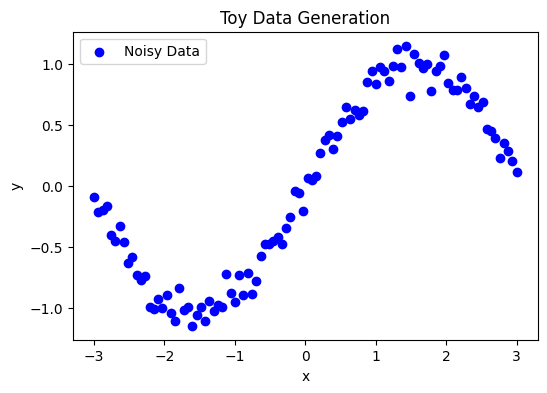

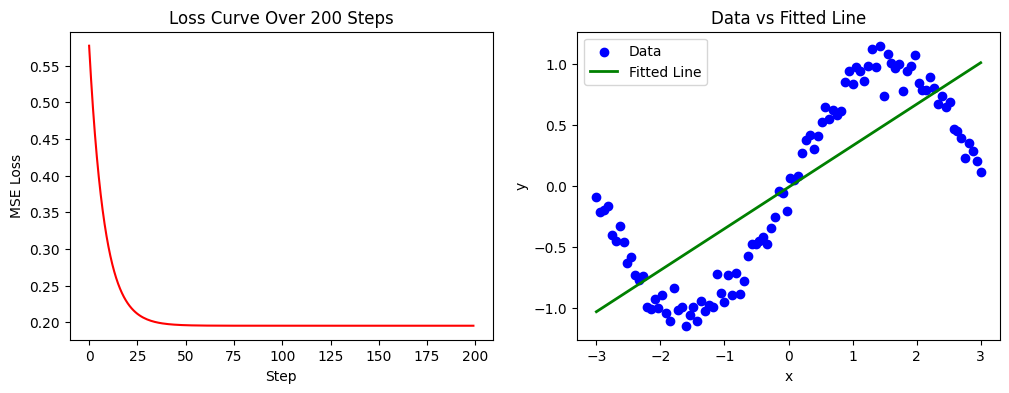

In [3]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, 100)
y = np.sin(x) + noise

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Noisy Data')
plt.title('Toy Data Generation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.01
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
for step in range(200):
    y_hat = w * x + b

    # mse
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #  calculat gradient
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # update weights and bias using learning rate
    w = w - lr * dw
    b = b - lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(12, 4))

# Plot (a) Loss Curve
plt.subplot(1, 2, 1)
plt.plot(losses, color='red')
plt.title('Loss Curve Over 200 Steps')
plt.xlabel('Step')
plt.ylabel('MSE Loss')

# Plot (b) Fitted Line
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, w * x + b, color='green', linewidth=2, label='Fitted Line')
plt.title('Data vs Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**Student Reasoning — The single neuron**

The loss function is

$$
\text{Loss}=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2.
$$

Where the y  with hat is:

$$
\hat{y}_i=wx_i+b.
$$

Substituting that y_hat into the loss function:

$$
\text{Loss}=\frac{1}{N}\sum_{i=1}^{N}(wx_i+b-y_i)^2.
$$

taking the partial derivative with respect to \(w\).

Using the chain rule,

$$
\frac{\partial}{\partial w}(u^2)=2u\frac{\partial u}{\partial w},
$$

where

$$
u=wx_i+b-y_i.
$$

Since xi, b, and yi are constants with respect to w, their derivative will be:

$$
\frac{\partial}{\partial w}(wx_i+b-y_i)=x_i.
$$


Therefore,

$$
\frac{\partial \text{Loss}}{\partial w}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(wx_i+b-y_i)x_i.
$$

Since

$$
\hat{y}_i=wx_i+b,
$$

the equation can also be written as

$$
\frac{\partial \text{Loss}}{\partial w}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(\hat{y}_i-y_i)x_i.
$$

taking the partial derivative with respect to \(b\).

The derivative of the inside term is

$$
\frac{\partial}{\partial b}(wx_i+b-y_i)=1.
$$

So,

$$
\frac{\partial \text{Loss}}{\partial b}
=
\frac{1}{N}
\sum_{i=1}^{N}
2(\hat{y}_i-y_i).
$$

These equations match the code because `np.mean()` calculates the average over all data points.


This is underfitting because the model is too simple to fit the data. A single neuron uses the equation y=wx+b, so it can only draw a straight line. A sine wave is a curved line that goes up and down. Because of this, a straight line cannot match the sine wave well. Even if we train the model for a longer time, it still cannot fit the sine wave because the model is too simple.
